# 🏎️ Módulo 2 — Dinâmica do Carro

Este notebook calcula grandezas físicas (forças G, frenagem) a partir 
da telemetria real de F1, conectando conceitos de cálculo e cinemática 
com dados de corrida.

**Exemplo usado:** GP da Espanha 2025

In [3]:
import sys
import os

# Adiciona a pasta raiz do projeto ao caminho de busca do Python
sys.path.append(os.path.abspath('..'))

import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.makedirs('../cache', exist_ok=True)
fastf1.Cache.enable_cache('../cache')

from funcoes_telemetria import (
    comparar_pilotos, encontrar_ponto_na_pista, mapa_velocidade,
    comparar_mapas_velocidade, analisar_stints, obter_dados_corrida,
    comparar_stints, ranking_sessao, calcular_g_longitudinal, calcular_g_lateral
)

print("Funções importadas com sucesso!")
print("Funções importadas com sucesso!")

Funções importadas com sucesso!
Funções importadas com sucesso!


# Cálculo do G longitudial
Usaremos Oscar Piastri como exemplo

In [4]:
session = fastf1.get_session(2025, 'Spain', 'Q')
session.load()

piastri = session.laps.pick_driver('PIA').pick_fastest()
tel_pia = piastri.get_telemetry().add_distance()

print("Telemetria carregada!")
print(tel_pia[['Distance', 'Speed', 'Time']].head())

core           INFO 	Loading data for Spanish Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '1', '63', '44', '12', '16', '10', '6', '14', '23', '5', '30', '18', '87', '27', '31', '55', '43', '22']
c:\Users\joaom\telemetria-f1\.venv\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is depre

Telemetria carregada!
    Distance       Speed                   Time
2   0.000000  300.435000        0 days 00:00:00
3   9.448056  301.000000 0 days 00:00:00.113000
4  12.882596  301.569444 0 days 00:00:00.154000
5  33.209448  304.902777 0 days 00:00:00.394000
6  39.924448  306.000000 0 days 00:00:00.473000


In [5]:
# Velocidade em m/s (a telemetria vem em km/h)
v_ms = tel_pia['Speed'].values / 3.6

# Tempo em segundos (a telemetria vem como Timedelta)
t_s = tel_pia['Time'].dt.total_seconds().values

# Derivada numérica: dv/dt usando np.diff (diferença entre pontos consecutivos)
dv = np.diff(v_ms)
dt = np.diff(t_s)

aceleracao = dv / dt  # m/s²
g_longitudinal = aceleracao / 9.81  # em múltiplos de g

print(f"Maior frenagem: {g_longitudinal.min():.2f} g")
print(f"Maior aceleração: {g_longitudinal.max():.2f} g")

Maior frenagem: -5.92 g
Maior aceleração: 1.62 g


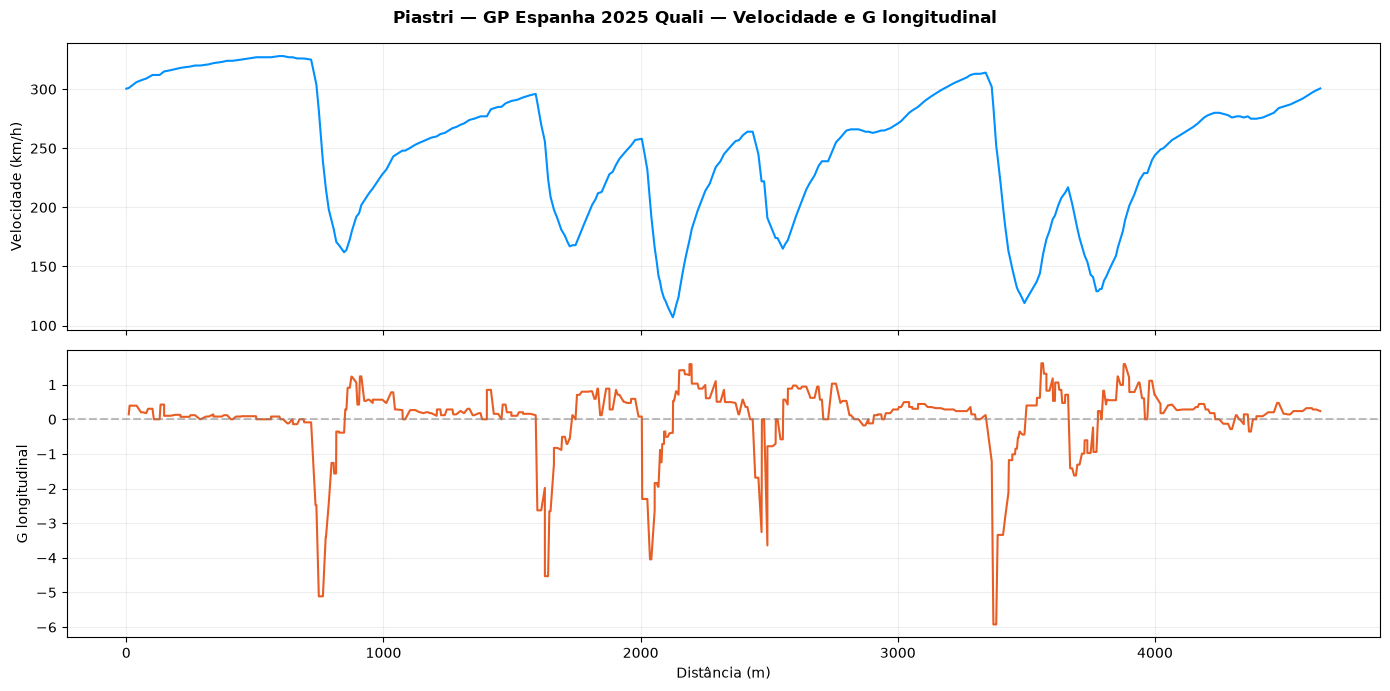

In [6]:
# Como g_longitudinal tem 1 elemento a menos, ajustamos a distância correspondente
distancia_g = tel_pia['Distance'].values[1:]  # remove o primeiro ponto

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(tel_pia['Distance'], tel_pia['Speed'], color='#0090FF')
axes[0].set_ylabel('Velocidade (km/h)')
axes[0].grid(alpha=0.2)

axes[1].plot(distancia_g, g_longitudinal, color='#E85D24')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('G longitudinal')
axes[1].set_xlabel('Distância (m)')
axes[1].grid(alpha=0.2)

fig.suptitle('Piastri — GP Espanha 2025 Quali — Velocidade e G longitudinal', fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Defino um limite mínimo razoável pro intervalo de tempo
dt_minimo = 0.01  # 10ms — abaixo disso, consideramos erro de amostragem

# Máscara booleana: True onde o dt é "saudável"
mascara_valida = dt >= dt_minimo

# Aplica o filtro em tudo que depende de dt
dv_filtrado = dv[mascara_valida]
dt_filtrado = dt[mascara_valida]
distancia_filtrada = distancia_g[mascara_valida]

aceleracao_filtrada = dv_filtrado / dt_filtrado
g_filtrado = aceleracao_filtrada / 9.81

print(f"Pontos originais: {len(dt)}")
print(f"Pontos após filtro: {len(dt_filtrado)}")
print(f"Maior frenagem (filtrado): {g_filtrado.min():.2f} g")
print(f"Maior aceleração (filtrado): {g_filtrado.max():.2f} g")

Pontos originais: 543
Pontos após filtro: 513
Maior frenagem (filtrado): -5.92 g
Maior aceleração (filtrado): 1.62 g


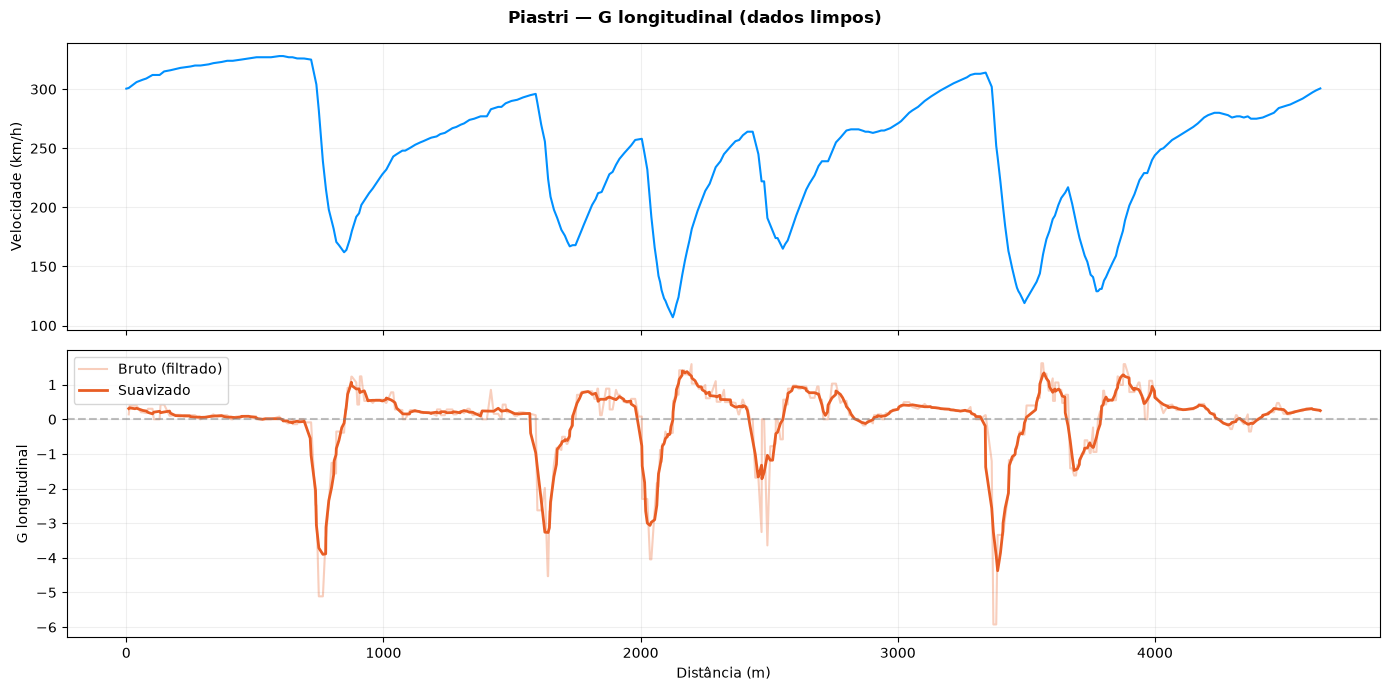

In [8]:
# Suaviza os dados já filtrados
v_para_suavizar = pd.Series(dv_filtrado / dt_filtrado)  # já é aceleração bruta
g_suave_filtrado = v_para_suavizar.rolling(window=5, center=True, min_periods=1).mean().values / 9.81

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(tel_pia['Distance'], tel_pia['Speed'], color='#0090FF')
axes[0].set_ylabel('Velocidade (km/h)')
axes[0].grid(alpha=0.2)

axes[1].plot(distancia_filtrada, g_filtrado, color='#E85D24', alpha=0.3, label='Bruto (filtrado)')
axes[1].plot(distancia_filtrada, g_suave_filtrado, color='#E85D24', linewidth=2, label='Suavizado')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('G longitudinal')
axes[1].set_xlabel('Distância (m)')
axes[1].legend()
axes[1].grid(alpha=0.2)

fig.suptitle('Piastri — G longitudinal (dados limpos)', fontweight='bold')
plt.tight_layout()
plt.show()

# Pós teste, como de costume, automatizamos...

In [9]:
def calcular_g_longitudinal(telemetria, dt_minimo=0.01, janela_suavizacao=5):
    """
    Calcula a força G longitudinal a partir da telemetria de uma volta.
    Filtra amostras com intervalo de tempo anormalmente pequeno (erro de sensor)
    e suaviza o resultado com média móvel.
    
    Retorna: distancia, g_bruto, g_suave (todos arrays numpy)
    """
    v_ms = telemetria['Speed'].values / 3.6
    t_s = telemetria['Time'].dt.total_seconds().values
    distancia = telemetria['Distance'].values
    
    dv = np.diff(v_ms)
    dt = np.diff(t_s)
    dist_pontos = distancia[1:]
    
    # Filtra dt anormalmente pequenos
    mascara_valida = dt >= dt_minimo
    dv_f = dv[mascara_valida]
    dt_f = dt[mascara_valida]
    dist_f = dist_pontos[mascara_valida]
    
    aceleracao = dv_f / dt_f
    g_bruto = aceleracao / 9.81
    
    g_suave = pd.Series(g_bruto).rolling(window=janela_suavizacao, center=True, min_periods=1).mean().values
    
    return dist_f, g_bruto, g_suave

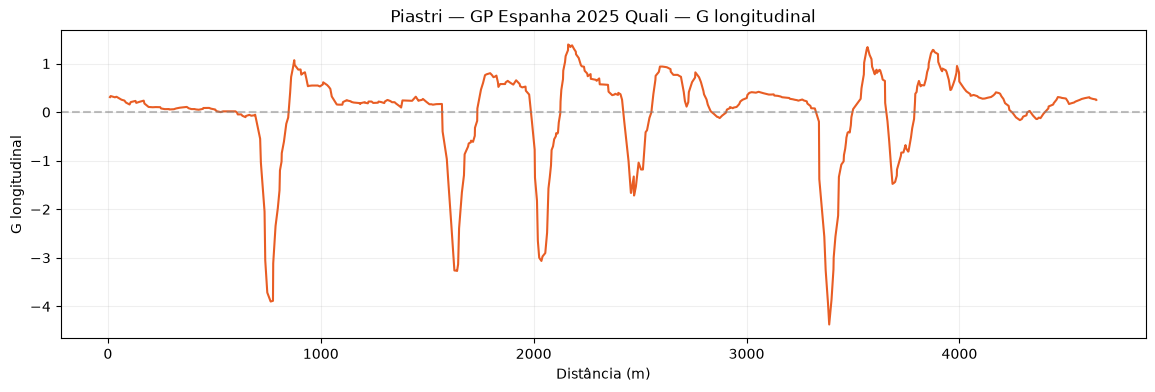

In [10]:
dist_pia, g_bruto_pia, g_suave_pia = calcular_g_longitudinal(tel_pia)

plt.figure(figsize=(14, 4))
plt.plot(dist_pia, g_suave_pia, color='#E85D24')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Distância (m)')
plt.ylabel('G longitudinal')
plt.title('Piastri — GP Espanha 2025 Quali — G longitudinal')
plt.grid(alpha=0.2)
plt.show()

# Cálculo do G lateral
Usaremos Leclerc de exemplo

In [11]:
def calcular_g_lateral(telemetria, janela_suavizacao=3):
    """
    Estima a força G lateral a partir da geometria da trajetória (X, Y),
    usando a distância percorrida como referência (mais estável que tempo).
    
    LIMITAÇÃO CONHECIDA: a derivação numérica de 2ª ordem tende a subestimar
    picos de curvatura em curvas fechadas. Use como aproximação relativa
    (comparação entre pilotos/curvas), não como valor absoluto preciso.
    """
    x = telemetria['X'].values
    y = telemetria['Y'].values
    v_ms = telemetria['Speed'].values / 3.6
    s = telemetria['Distance'].values
    
    dx = np.gradient(x, s)
    dy = np.gradient(y, s)
    ddx = np.gradient(dx, s)
    ddy = np.gradient(dy, s)
    
    numerador = np.abs(dx * ddy - dy * ddx)
    denominador = (dx**2 + dy**2)**1.5
    denominador = np.where(denominador < 1e-9, 1e-9, denominador)
    curvatura = numerador / denominador
    
    raio = 1 / np.where(curvatura < 1e-6, 1e-6, curvatura)
    aceleracao_lateral = (v_ms**2) / raio
    g_lateral = aceleracao_lateral / 9.81
    
    g_suave = pd.Series(g_lateral).rolling(window=janela_suavizacao, center=True, min_periods=1).mean().values
    
    return s, g_lateral, g_suave

In [12]:
leclerc = session.laps.pick_driver('LEC').pick_fastest()
tel_lec = leclerc.get_telemetry().add_distance()

print("Telemetria do Leclerc carregada!")

c:\Users\joaom\telemetria-f1\.venv\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


Telemetria do Leclerc carregada!


In [13]:
dist_lec, g_bruto_lec, g_suave_lec = calcular_g_lateral(tel_lec)

print(f"Maior G lateral (Leclerc): {np.abs(g_suave_lec).max():.2f} g")

Maior G lateral (Leclerc): 0.63 g


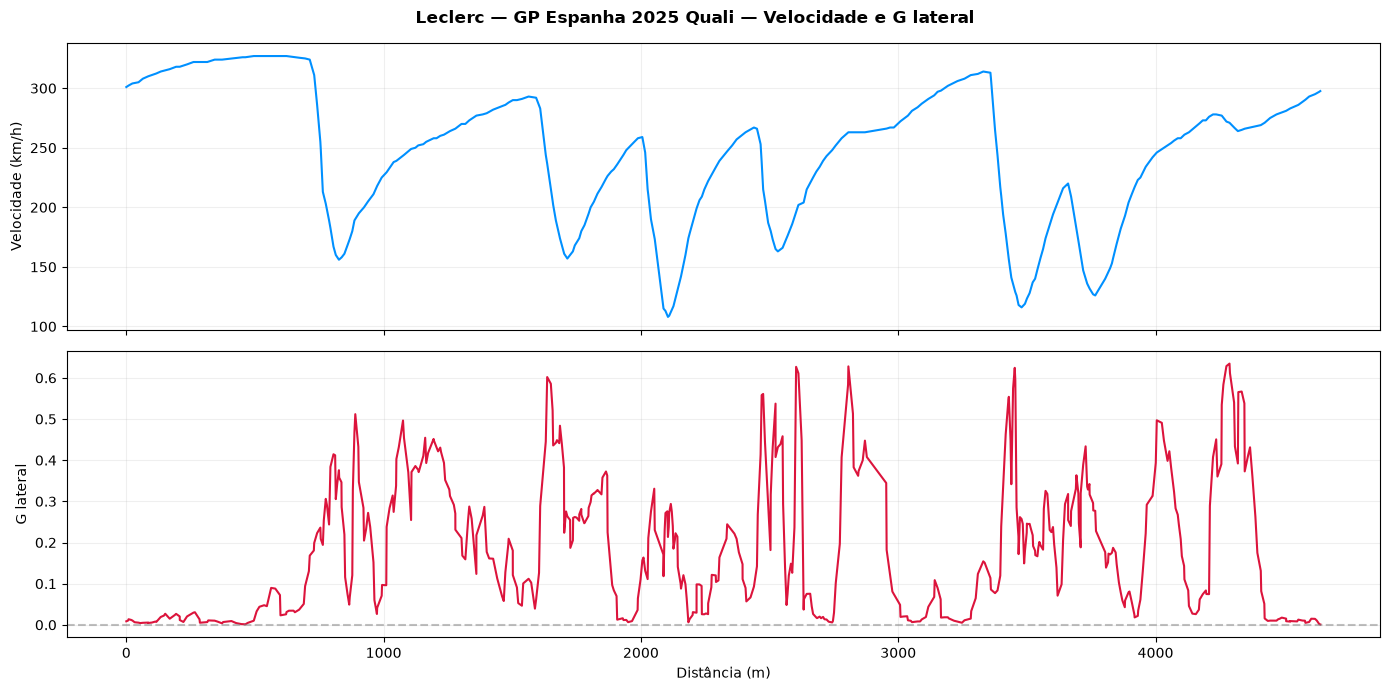

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(tel_lec['Distance'], tel_lec['Speed'], color='#0090FF')
axes[0].set_ylabel('Velocidade (km/h)')
axes[0].grid(alpha=0.2)

axes[1].plot(dist_lec, g_suave_lec, color='#DC143C')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('G lateral')
axes[1].set_xlabel('Distância (m)')
axes[1].grid(alpha=0.2)

fig.suptitle('Leclerc — GP Espanha 2025 Quali — Velocidade e G lateral', fontweight='bold')
plt.tight_layout()
plt.show()

# Avaliando possível erro...

In [15]:
x = tel_lec['X'].values
y = tel_lec['Y'].values
s = tel_lec['Distance'].values

dx = np.gradient(x, s)
dy = np.gradient(y, s)
ddx = np.gradient(dx, s)
ddy = np.gradient(dy, s)

print(f"dx - min: {dx.min():.4f}, max: {dx.max():.4f}")
print(f"dy - min: {dy.min():.4f}, max: {dy.max():.4f}")
print(f"ddx - min: {ddx.min():.6f}, max: {ddx.max():.6f}")
print(f"ddy - min: {ddy.min():.6f}, max: {ddy.max():.6f}")

curvatura = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**1.5
raio = 1 / np.where(curvatura < 1e-6, 1e-6, curvatura)

print(f"\nRaio mínimo: {raio.min():.1f} m")
print(f"Raio máximo (sem o piso): {np.sort(raio)[-10]:.1f} m")  # 10º maior, ignora outliers extremos
print(f"Raio médio: {raio.mean():.1f} m")
print(f"Raio mediano: {np.median(raio):.1f} m")

dx - min: -16.4246, max: 14.7045
dy - min: -14.7333, max: 14.6968
ddx - min: -0.843712, max: 0.789678
ddy - min: -0.736878, max: 1.140809

Raio mínimo: 119.0 m
Raio máximo (sem o piso): 402014.0 m
Raio médio: 35231.4 m
Raio mediano: 2671.7 m


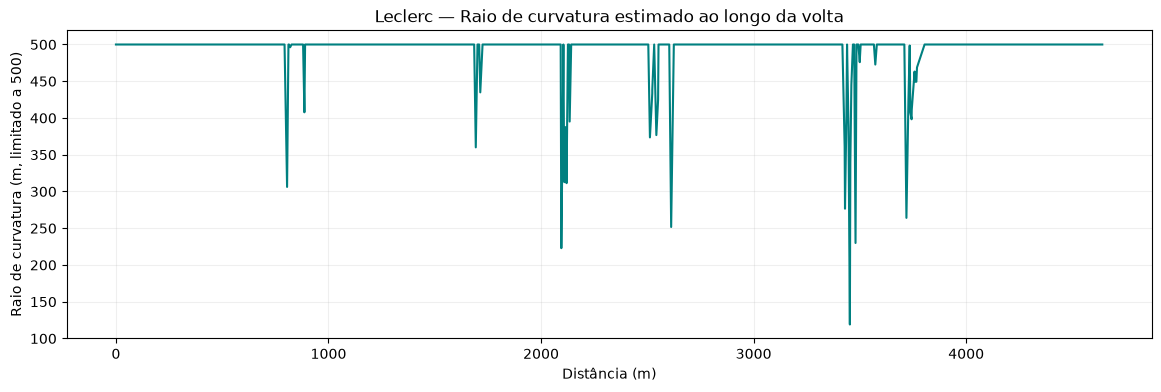

In [16]:
x = tel_lec['X'].values
y = tel_lec['Y'].values
s = tel_lec['Distance'].values

dx = np.gradient(x, s)
dy = np.gradient(y, s)
ddx = np.gradient(dx, s)
ddy = np.gradient(dy, s)

curvatura = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**1.5
raio = 1 / np.where(curvatura < 1e-6, 1e-6, curvatura)

# Limita visualmente o raio pra não deixar a escala dominada pelas retas (raio gigante)
raio_plotavel = np.clip(raio, 0, 500)

plt.figure(figsize=(14, 4))
plt.plot(s, raio_plotavel, color='teal')
plt.xlabel('Distância (m)')
plt.ylabel('Raio de curvatura (m, limitado a 500)')
plt.title('Leclerc — Raio de curvatura estimado ao longo da volta')
plt.grid(alpha=0.2)
plt.show()

In [17]:
# Pega a velocidade no ponto de raio mínimo (~3400m, La Caixa)
idx_raio_min = np.argmin(raio)
print(f"Distância do raio mínimo: {s[idx_raio_min]:.0f} m")
print(f"Raio nesse ponto: {raio[idx_raio_min]:.1f} m")
print(f"Velocidade nesse ponto: {tel_lec['Speed'].iloc[idx_raio_min]:.0f} km/h")

v_ms_local = tel_lec['Speed'].iloc[idx_raio_min] / 3.6
g_calculado = (v_ms_local**2 / raio[idx_raio_min]) / 9.81
print(f"G lateral calculado nesse ponto: {g_calculado:.2f} g")

# Agora pega o ponto de Turn 3 (Renault), que sabemos que chega a 4g segundo fontes externas
# Geralmente fica entre 600-1000m no traçado, vamos varrer essa faixa
mascara_t3 = (s > 600) & (s < 1000)
idx_t3_max_g = None
g_max_t3 = 0
for i in np.where(mascara_t3)[0]:
    v_local = tel_lec['Speed'].iloc[i] / 3.6
    g_local = (v_local**2 / raio[i]) / 9.81
    if g_local > g_max_t3:
        g_max_t3 = g_local
        idx_t3_max_g = i

print(f"\nG lateral máximo estimado na zona da Turn 3 (~600-1000m): {g_max_t3:.2f} g")

Distância do raio mínimo: 3453 m
Raio nesse ponto: 119.0 m
Velocidade nesse ponto: 130 km/h
G lateral calculado nesse ponto: 1.12 g

G lateral máximo estimado na zona da Turn 3 (~600-1000m): 0.72 g


In [18]:
# Calcula o G lateral em TODOS os pontos da volta (sem suavização ainda)
v_ms_full = tel_lec['Speed'].values / 3.6
g_lateral_full = (v_ms_full**2 / raio) / 9.81

# Acha os 10 maiores picos de G lateral, ignorando pontos vizinhos repetidos
indices_ordenados = np.argsort(g_lateral_full)[::-1]  # do maior pro menor

print("Top 10 picos de G lateral na volta:")
print(f"{'Distância (m)':>15} | {'G lateral':>10} | {'Velocidade (km/h)':>18} | {'Raio (m)':>10}")
for idx in indices_ordenados[:10]:
    print(f"{s[idx]:>15.0f} | {g_lateral_full[idx]:>10.2f} | {tel_lec['Speed'].iloc[idx]:>18.0f} | {raio[idx]:>10.1f}")

Top 10 picos de G lateral na volta:
  Distância (m) |  G lateral |  Velocidade (km/h) |   Raio (m)
           2612 |       1.28 |                202 |      251.7
           3453 |       1.12 |                130 |      119.0
           4335 |       0.95 |                265 |      584.2
           2806 |       0.75 |                263 |      726.8
           4223 |       0.72 |                278 |      843.4
            805 |       0.72 |                167 |      306.2
           2805 |       0.70 |                263 |      775.1
           3430 |       0.69 |                156 |      276.6
            887 |       0.69 |                189 |      407.8
           1650 |       0.68 |                216 |      537.3


## ⚠️ Nota sobre precisão do G lateral

O cálculo de G lateral feito aqui estima a curvatura da trajetória a 
partir das coordenadas X, Y usando derivadas numéricas de segunda ordem 
(`np.gradient` aplicado duas vezes). 

**Limitação identificada:** os valores calculados (pico de ~1.3g) ficam 
consistentemente abaixo de referências externas para a F1 real (3-5g em 
curvas rápidas como a Turn 3 de Barcelona). Isso é uma limitação conhecida 
da técnica, não um erro de implementação — derivar numericamente em duas 
etapas amplifica imprecisões da medição original e tende a suavizar picos 
estreitos de curvatura, subestimando o pico real nas curvas mais fechadas.

Telemetria profissional de F1 usa acelerômetros dedicados (medição direta) 
em vez de derivar da posição, justamente para evitar esse problema. Esse 
notebook usa a abordagem geométrica por ser a que está disponível nos 
dados públicos do FastF1, mas os valores devem ser interpretados como uma 
**aproximação por ordem de grandeza**, não como medição precisa.

Testes finais:

In [19]:
verstappen = session.laps.pick_driver('VER').pick_fastest()
tel_ver = verstappen.get_telemetry().add_distance()

print("Telemetria do Verstappen carregada!")

c:\Users\joaom\telemetria-f1\.venv\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


Telemetria do Verstappen carregada!


In [20]:
dist_ver, g_bruto_ver, g_suave_ver = calcular_g_lateral(tel_ver)

print(f"Maior G lateral (Verstappen): {np.abs(g_suave_ver).max():.2f} g")

Maior G lateral (Verstappen): 1.05 g


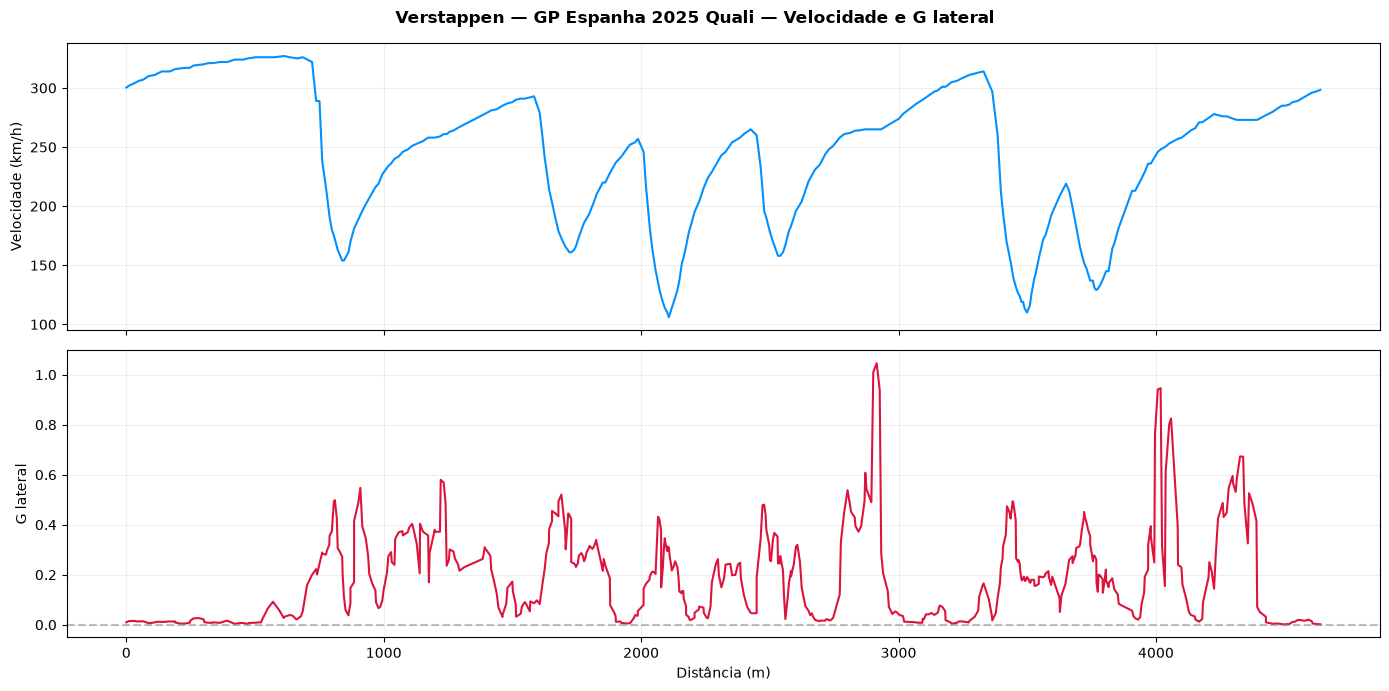

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(tel_ver['Distance'], tel_ver['Speed'], color='#0090FF')
axes[0].set_ylabel('Velocidade (km/h)')
axes[0].grid(alpha=0.2)

axes[1].plot(dist_ver, g_suave_ver, color='#DC143C')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('G lateral')
axes[1].set_xlabel('Distância (m)')
axes[1].grid(alpha=0.2)

fig.suptitle('Verstappen — GP Espanha 2025 Quali — Velocidade e G lateral', fontweight='bold')
plt.tight_layout()
plt.show()

# Comparando dois pilotos

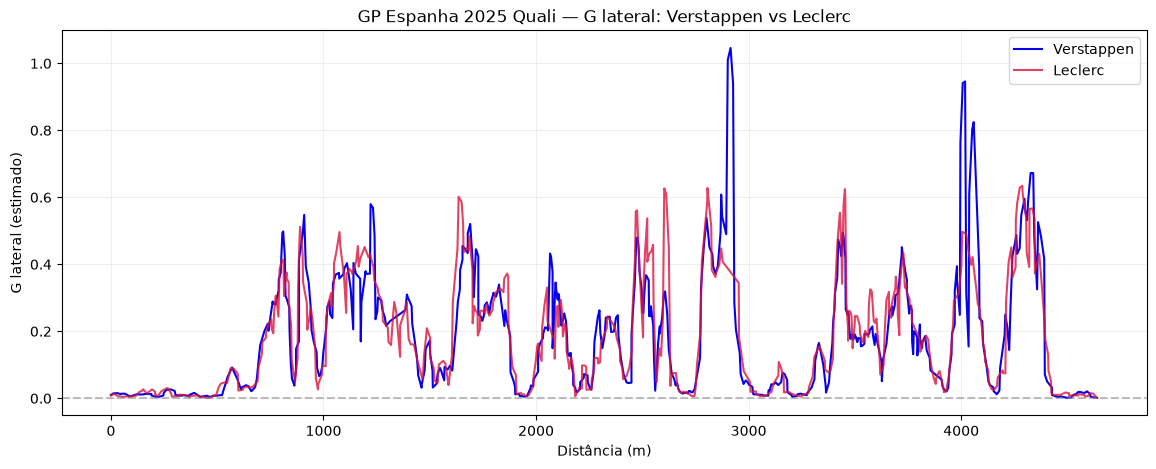

In [22]:
dist_ver, g_bruto_ver, g_suave_ver = calcular_g_lateral(tel_ver)
dist_lec, g_bruto_lec, g_suave_lec = calcular_g_lateral(tel_lec)

plt.figure(figsize=(14, 5))
plt.plot(dist_ver, g_suave_ver, color='#0600EF', label='Verstappen', linewidth=1.5)
plt.plot(dist_lec, g_suave_lec, color='#DC143C', label='Leclerc', linewidth=1.5, alpha=0.8)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Distância (m)')
plt.ylabel('G lateral (estimado)')
plt.title('GP Espanha 2025 Quali — G lateral: Verstappen vs Leclerc')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# Comparação entre velocidade e G lateral e longitudial

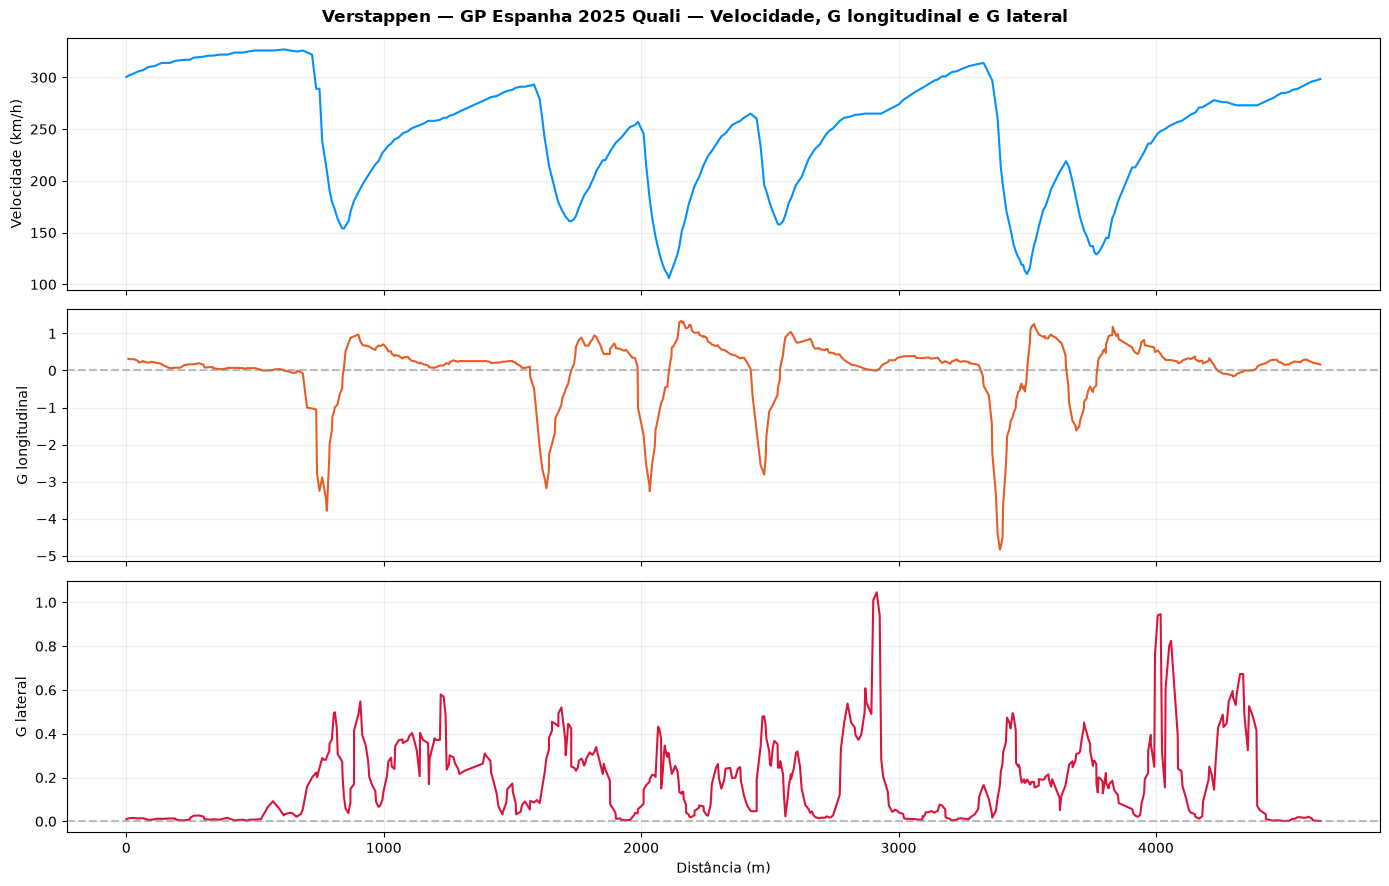

In [23]:
dist_g_long, g_bruto_long, g_suave_long = calcular_g_longitudinal(tel_ver)
dist_g_lat, g_bruto_lat, g_suave_lat = calcular_g_lateral(tel_ver)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(tel_ver['Distance'], tel_ver['Speed'], color='#0090FF')
axes[0].set_ylabel('Velocidade (km/h)')
axes[0].grid(alpha=0.2)

axes[1].plot(dist_g_long, g_suave_long, color='#E85D24')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('G longitudinal')
axes[1].grid(alpha=0.2)

axes[2].plot(dist_g_lat, g_suave_lat, color='#DC143C')
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_ylabel('G lateral')
axes[2].set_xlabel('Distância (m)')
axes[2].grid(alpha=0.2)

fig.suptitle('Verstappen — GP Espanha 2025 Quali — Velocidade, G longitudinal e G lateral', fontweight='bold')
plt.tight_layout()
plt.show()